In [1]:
!gdown --id 1OjN2XN2aIGbTKlJ9qyCX1dW0kGUbLnwx

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1OjN2XN2aIGbTKlJ9qyCX1dW0kGUbLnwx
To: /kaggle/working/llm_judged_results.csv
100%|███████████████████████████████████████| 1.21M/1.21M [00:00<00:00, 110MB/s]


In [2]:
import pandas as pd

data = pd.read_csv("/kaggle/working/llm_judged_results.csv")

In [3]:
data.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,passage_id,reference_passage,reference_difficulty,reference_category,reference_question_type,reference_instruction,reference_question,reference_answer,generated_instruction,generated_question,...,generated_full_output,answerability_score,clarity_score,relevance_score,judged_difficulty,judged_question_type,error,usage_prompt_tokens,usage_completion_tokens,usage_total_tokens
0,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",a reference to the influence of the domestic b...,A,"Reading Passage 2 has seven paragraphs, A-H . ...",an example of how children’s IQ scores are det...,...,Instruction: Reading Passage 2 has seven parag...,9,7,8,Medium,readingMatchingFeatures,NaN,1215,51,1266
1,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",reference to what can be lost if learners are ...,D,"Reading Passage 2 has seven paragraphs, A-H . ...",an example of how children’s IQ scores are det...,...,Instruction: Reading Passage 2 has seven parag...,7,7,6,Medium,readingMatchingFeatures,NaN,1215,51,1266
2,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",a reference to the damaging effects of anxiety.,F,"Reading Passage 2 has seven paragraphs, A-H . ...",an example of how children’s IQ scores are det...,...,Instruction: Reading Passage 2 has seven parag...,8,7,8,Medium,readingMatchingFeatures,NaN,1215,51,1266
3,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",examples of classroom techniques which favour ...,D,"Reading Passage 2 has seven paragraphs, A-H . ...",an example of how children’s IQ scores are det...,...,Instruction: Reading Passage 2 has seven parag...,7,8,6,Medium,readingMatchingFeatures,NaN,1215,51,1266
4,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,Look at the following statements (Questions 18...,Less time can be spent on exercises with gifte...,B,"Reading Passage 2 has seven paragraphs, A-H . ...",an example of how children’s IQ scores are det...,...,Instruction: Reading Passage 2 has seven parag...,8,7,7,Hard,readingMatchingFeatures,NaN,1215,51,1266


In [4]:

required_score_cols = ["answerability_score", "clarity_score", "relevance_score"]
for c in required_score_cols:
    if c not in data.columns:
        raise ValueError(f"Column '{c}' not found in evaluation CSV.")

score_means = {f"{c}_mean": float(data[c].mean()) for c in required_score_cols}
score_means


{'answerability_score_mean': 7.45,
 'clarity_score_mean': 8.81,
 'relevance_score_mean': 7.305}

In [5]:
import json

for c in ["judged_difficulty", "judged_question_type"]:
    if c not in data.columns:
        raise ValueError(f"Column '{c}' not found in evaluation CSV.")

for c in ["reference_difficulty", "reference_question_type"]:
    if c not in data.columns:
        raise ValueError(f"Column '{c}' not found in generated CSV.")

eval_df = data.copy()
gen_df = data.copy()
eval_df["__row_id__"] = range(len(eval_df))
gen_df["__row_id__"] = range(len(gen_df))

merged = pd.merge(
    eval_df[["__row_id__", "passage_id", "judged_difficulty", "judged_question_type"]],
    gen_df[["__row_id__", "passage_id", "reference_difficulty", "reference_question_type"]],
    on="__row_id__",
    suffixes=("_eval", "_gen"),
    how="inner"
)

def norm(x):
    return str(x).strip().lower()

merged["difficulty_match"] = (merged["judged_difficulty"].map(norm) == merged["reference_difficulty"].map(norm)).astype(int)
merged["qtype_match"] = (merged["judged_question_type"].map(norm) == merged["reference_question_type"].map(norm)).astype(int)

difficulty_accuracy = float(merged["difficulty_match"].mean()) if len(merged) else 0.0
qtype_accuracy = float(merged["qtype_match"].mean()) if len(merged) else 0.0

summary = {
    "score_means": score_means,
    "comparisons": {
        "difficulty_match_count": int(merged["difficulty_match"].sum()),
        "difficulty_total": int(len(merged)),
        "difficulty_accuracy": round(difficulty_accuracy, 4),
        "qtype_match_count": int(merged["qtype_match"].sum()),
        "qtype_total": int(len(merged)),
        "qtype_accuracy": round(qtype_accuracy, 4),
    }
}

print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "score_means": {
    "answerability_score_mean": 7.45,
    "clarity_score_mean": 8.81,
    "relevance_score_mean": 7.305
  },
  "comparisons": {
    "difficulty_match_count": 130,
    "difficulty_total": 200,
    "difficulty_accuracy": 0.65,
    "qtype_match_count": 157,
    "qtype_total": 200,
    "qtype_accuracy": 0.785
  }
}


## **Tables and Charts**

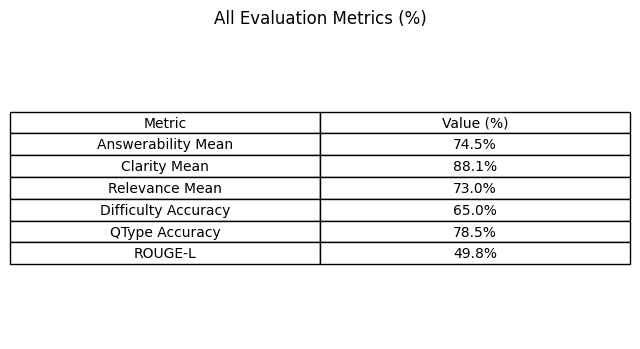

/tmp/ipykernel_48/3901389801.py:64: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels, rotation=20, ha='right')


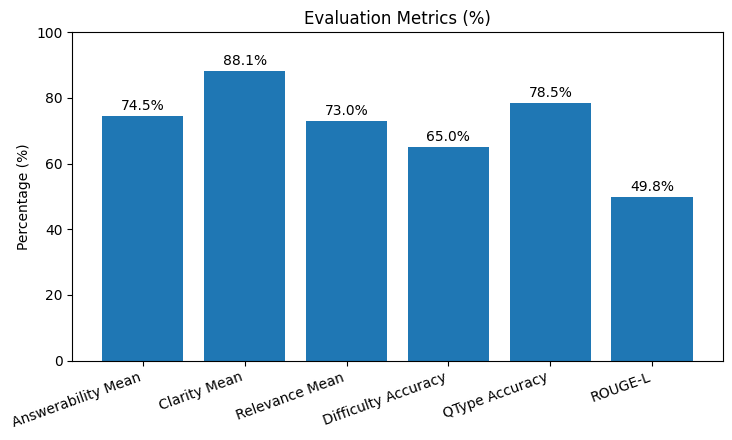

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# ====== داده‌های شما ======
results = {
    "score_means": {
        "answerability_score_mean": 7.45,
        "clarity_score_mean": 8.81,
        "relevance_score_mean": 7.305
    },
    "comparisons": {
        "difficulty_match_count": 130,
        "difficulty_total": 200,
        "difficulty_accuracy": 0.65,   # 65%
        "qtype_match_count": 157,
        "qtype_total": 200,
        "qtype_accuracy": 0.785        # 78.5%
    },
    "eval_rougeL": 0.49795442064066625
}

# ====== تبدیل همه‌ی معیارها به درصد ======
percent_metrics = {
    "Answerability Mean": results["score_means"]["answerability_score_mean"] / 10 * 100,
    "Clarity Mean":       results["score_means"]["clarity_score_mean"] / 10 * 100,
    "Relevance Mean":     results["score_means"]["relevance_score_mean"] / 10 * 100,
    "Difficulty Accuracy": results["comparisons"]["difficulty_accuracy"] * 100,
    "QType Accuracy":      results["comparisons"]["qtype_accuracy"] * 100,
    "ROUGE-L":             results["eval_rougeL"] * 100
}

# دیتافریم برای جدول
df_pct = pd.DataFrame(
    [(k, f"{v:.1f}%") for k, v in percent_metrics.items()],
    columns=["Metric", "Value (%)"]
)

# ====== 1) جدول درصدها با matplotlib ======
fig_tbl, ax_tbl = plt.subplots(figsize=(6.5, 3.6))
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=df_pct.values,
    colLabels=df_pct.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.2)
plt.title("All Evaluation Metrics (%)", pad=10, fontsize=12)
plt.tight_layout()
plt.show()

# ====== 2) نمودار میله‌ای درصدها ======
labels = list(percent_metrics.keys())
values = list(percent_metrics.values())

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(labels, values)

ax.set_ylim(0, 100)
ax.set_ylabel("Percentage (%)")
ax.set_title("Evaluation Metrics (%)")
ax.set_xticklabels(labels, rotation=20, ha='right')

# برچسب درصد روی هر ستون
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


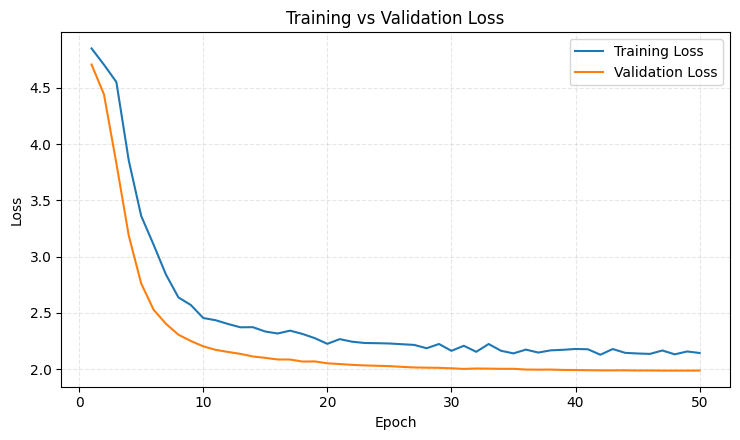

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

# -------- داده‌های چندخطی (همان که قبلاً فرستادی) --------
raw = """
Epoch	Training Loss	Validation Loss	Pred Len	Rougel
1	4.850400	4.707206	17.129707	0.083047
2	4.705900	4.441675	16.811715	0.085916
3	4.551800	3.829107	38.364017	0.114300
4	3.853200	3.185659	62.188285	0.147254
5	3.361300	2.760617	41.029289	0.331438
6	3.105600	2.527462	45.619247	0.359459
7	2.839300	2.401798	51.267782	0.390384
8	2.636800	2.305424	45.790795	0.434962
9	2.569500	2.249485	46.648536	0.439259
10	2.453900	2.201935	45.121339	0.456774
11	2.434000	2.170649	46.033473	0.473319
12	2.400700	2.152074	45.297071	0.475755
13	2.371200	2.134786	46.598326	0.487913
14	2.372300	2.111900	50.460251	0.483048
15	2.333600	2.099553	45.163180	0.494658
16	2.316000	2.085111	44.686192	0.496032
17	2.341400	2.084550	46.184100	0.493530
18	2.312100	2.066674	46.794979	0.490619
19	2.274200	2.067785	44.221757	0.499964
20	2.224300	2.050783	46.686192	0.497906
21	2.266100	2.044521	48.364017	0.494093
22	2.243000	2.037110	45.163180	0.505727
23	2.231800	2.032208	43.849372	0.502560
24	2.229900	2.029139	43.209205	0.508108
25	2.227300	2.025900	43.882845	0.503085
26	2.220800	2.019516	43.916318	0.502327
27	2.214600	2.014177	44.121339	0.506583
28	2.184900	2.012262	42.635983	0.502599
29	2.222700	2.010935	44.163180	0.502387
30	2.161900	2.006679	44.046025	0.499535
31	2.206900	2.001372	43.594142	0.506795
32	2.153300	2.004751	44.167364	0.501680
33	2.222600	2.003723	43.631799	0.506381
34	2.162400	2.002162	44.481172	0.500846
35	2.139300	2.002149	43.983264	0.501090
36	2.172900	1.995619	43.979079	0.503510
37	2.146600	1.994513	44.518828	0.503487
38	2.166300	1.995327	44.569038	0.503443
39	2.171100	1.992095	44.351464	0.502901
40	2.178600	1.991488	44.656904	0.500601
41	2.175900	1.989599	45.000000	0.499344
42	2.127300	1.988396	44.619247	0.500190
43	2.178000	1.988248	44.782427	0.501397
44	2.144100	1.988851	44.355649	0.502447
45	2.138400	1.986949	44.615063	0.499922
46	2.134700	1.987365	44.422594	0.502058
47	2.165000	1.986115	44.769874	0.497579
48	2.130900	1.986347	44.740586	0.499388
49	2.156400	1.986114	44.861925	0.498946
50	2.142800	1.986620	44.861925	0.498946
"""

# -------- خواندن به DataFrame --------
try:
    df = pd.read_csv(StringIO(raw), sep="\t")
except Exception:
    df = pd.read_csv(StringIO(raw), delim_whitespace=True)

df.columns = ["Epoch", "Training_Loss", "Validation_Loss", "Pred_Len", "ROUGE_L"]
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# -------- نمودار «Training vs Validation Loss» در یک شکل --------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(df["Epoch"], df["Training_Loss"], label="Training Loss")    # رنگ‌ها پیش‌فرض متفاوت‌اند
ax.plot(df["Epoch"], df["Validation_Loss"], label="Validation Loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## **Comparison with other models**

### **T5, BART, and GPT2 models** 

In [9]:
!gdown --id 1R2u5JS03SmaM7KP3kl8wE1XmSxILzh9s
!gdown --id 1Gmphs4fQrsFiJ8ckpFbjaoNEbstwpR0n

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1R2u5JS03SmaM7KP3kl8wE1XmSxILzh9s
To: /kaggle/working/llm_judged_results_T5.csv
100%|███████████████████████████████████████| 1.21M/1.21M [00:00<00:00, 117MB/s]
/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Gmphs4fQrsFiJ8ckpFbjaoNEbstwpR0n
To: /kaggle/working/llm_judged_results_BART.csv
100%|██████████████████████████████████████| 1.21M/1.21M [00:00<00:00, 61.5MB/s]


In [10]:
import pandas as pd

data_T5 = pd.read_csv("/kaggle/working/llm_judged_results_T5.csv")
data_BART = pd.read_csv("/kaggle/working/llm_judged_results_BART.csv")

In [11]:
data_T5.head(2)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,passage_id,reference_passage,reference_difficulty,reference_category,reference_question_type,reference_instruction,reference_question,reference_answer,generated_instruction,generated_question,...,generated_full_output,answerability_score,clarity_score,relevance_score,judged_difficulty,judged_question_type,error,usage_prompt_tokens,usage_completion_tokens,usage_total_tokens
0,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",a reference to the influence of the domestic b...,A,"Reading Passage 1 has eight paragraphs, A-G . ...",IQ tests can neither identify the processes of...,...,Instruction: Reading Passage 1 has eight parag...,10,8,9,Hard,readingShortAnswer,NaN,1229,51,1280
1,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",reference to what can be lost if learners are ...,D,"Reading Passage 1 has eight paragraphs, A-G . ...",IQ tests can neither identify the processes of...,...,Instruction: Reading Passage 1 has eight parag...,8,6,7,Hard,readingShortAnswer,NaN,1229,51,1280


In [12]:
data_BART.head(2)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,passage_id,reference_passage,reference_difficulty,reference_category,reference_question_type,reference_instruction,reference_question,reference_answer,generated_instruction,generated_question,...,generated_full_output,answerability_score,clarity_score,relevance_score,judged_difficulty,judged_question_type,error,usage_prompt_tokens,usage_completion_tokens,usage_total_tokens
0,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",a reference to the influence of the domestic b...,A,"Reading Passage 2 has eight paragraphs, A-G .\...","The vocabulary aspect, for example, is depende...",...,Instruction: Reading Passage 2 has eight parag...,2,3,1,Hard,readingMatchingFeatures,NaN,1255,51,1306
1,6ee08a73098c0dfbf0ba09711c20b6b3,"Internationally, ‘giftedness’ is most frequent...",Hard,Education/Psychology,readingMatchingFeatures,"Reading Passage 2 has six paragraphs, A-F .\nW...",reference to what can be lost if learners are ...,D,"Reading Passage 2 has eight paragraphs, A-G .\...","The vocabulary aspect, for example, is depende...",...,Instruction: Reading Passage 2 has eight parag...,2,3,1,Hard,readingMatchingFeatures,NaN,1255,51,1306


In [18]:
required_score_cols = ["answerability_score", "clarity_score", "relevance_score"]
for c in required_score_cols:
    if c not in data_T5.columns:
        raise ValueError(f"Column '{c}' not found in evaluation CSV.")

score_means_T5 = {f"{c}_mean": float(data_T5[c].mean()) for c in required_score_cols}
score_means_T5

{'answerability_score_mean': 4.175,
 'clarity_score_mean': 7.03,
 'relevance_score_mean': 4.8}

In [19]:
required_score_cols = ["answerability_score", "clarity_score", "relevance_score"]
for c in required_score_cols:
    if c not in data_BART.columns:
        raise ValueError(f"Column '{c}' not found in evaluation CSV.")

score_means_BART = {f"{c}_mean": float(data_BART[c].mean()) for c in required_score_cols}
score_means_BART

{'answerability_score_mean': 5.925,
 'clarity_score_mean': 7.32,
 'relevance_score_mean': 5.845}

In [20]:
def calculate_metrics(data, score_means):
    import json
    
    for c in ["judged_difficulty", "judged_question_type"]:
        if c not in data.columns:
            raise ValueError(f"Column '{c}' not found in evaluation CSV.")
    
    for c in ["reference_difficulty", "reference_question_type"]:
        if c not in data.columns:
            raise ValueError(f"Column '{c}' not found in generated CSV.")
    
    eval_df = data.copy()
    gen_df = data.copy()
    eval_df["__row_id__"] = range(len(eval_df))
    gen_df["__row_id__"] = range(len(gen_df))
    
    merged = pd.merge(
        eval_df[["__row_id__", "passage_id", "judged_difficulty", "judged_question_type"]],
        gen_df[["__row_id__", "passage_id", "reference_difficulty", "reference_question_type"]],
        on="__row_id__",
        suffixes=("_eval", "_gen"),
        how="inner"
    )
    
    def norm(x):
        return str(x).strip().lower()
    
    merged["difficulty_match"] = (merged["judged_difficulty"].map(norm) == merged["reference_difficulty"].map(norm)).astype(int)
    merged["qtype_match"] = (merged["judged_question_type"].map(norm) == merged["reference_question_type"].map(norm)).astype(int)
    
    difficulty_accuracy = float(merged["difficulty_match"].mean()) if len(merged) else 0.0
    qtype_accuracy = float(merged["qtype_match"].mean()) if len(merged) else 0.0
    
    summary = {
        "score_means": score_means,
        "comparisons": {
            "difficulty_match_count": int(merged["difficulty_match"].sum()),
            "difficulty_total": int(len(merged)),
            "difficulty_accuracy": round(difficulty_accuracy, 4),
            "qtype_match_count": int(merged["qtype_match"].sum()),
            "qtype_total": int(len(merged)),
            "qtype_accuracy": round(qtype_accuracy, 4),
        }
    }
    
    print(json.dumps(summary, ensure_ascii=False, indent=2))

In [21]:
print("T5 evaluation: ")
calculate_metrics(data_T5, score_means_T5)
print("BART evaluation: ")
calculate_metrics(data_BART, score_means_BART)
print("GPT2 evaluation: ")

T5 evaluation: 
{
  "score_means": {
    "answerability_score_mean": 4.175,
    "clarity_score_mean": 7.03,
    "relevance_score_mean": 4.8
  },
  "comparisons": {
    "difficulty_match_count": 94,
    "difficulty_total": 200,
    "difficulty_accuracy": 0.47,
    "qtype_match_count": 149,
    "qtype_total": 200,
    "qtype_accuracy": 0.745
  }
}
BART evaluation: 
{
  "score_means": {
    "answerability_score_mean": 5.925,
    "clarity_score_mean": 7.32,
    "relevance_score_mean": 5.845
  },
  "comparisons": {
    "difficulty_match_count": 114,
    "difficulty_total": 200,
    "difficulty_accuracy": 0.57,
    "qtype_match_count": 140,
    "qtype_total": 200,
    "qtype_accuracy": 0.7
  }
}
GPT2 evaluation: 
